> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 5: EDA

## Outline

- Univariate analysis (distributions, histograms, counts)
- Bivariate analysis (correlations, scatterplots, group comparisons)
- Reflections and insights

This lab uses the same dataset from **Lab 4**. You will see some overlap in the initial tasks as the data is cleaned.  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## SF Rentals - Business Context

This dataset represents actual rental listings in the San Francisco housing market, which is known for its high prices, competitive demand, and neighborhood-level variation. In a business context, this type of data could be used by real estate companies, rental platforms, investors, or property managers to better understand pricing trends and market dynamics. The variables provide multiple angles for analysis: pricing (price) can be compared with property features like size (sqft), bedrooms and bathrooms, and whether the listing is a full apartment or just a room; location data (nhood, lat, lon) allows for geographic analysis of rent differences across neighborhoods; and time variables (date, year) help track how the market changes over time. Text fields like title and descr can even be analyzed to understand how listings are marketed. By exploring this dataset, analysts can answer questions such as what factors drive higher rent, which neighborhoods are most expensive, or how prices have changed over time. This kind of analysis is valuable for setting competitive prices, identifying investment opportunities, and helping renters or companies make informed housing decisions.

Note that many of the columns (variables) will be empty.  This is an unfortunate reality in the real world!

Some rentals are apartments, others are for homes, and there may be some other random properties for rent.  Each row represents one rental listing.

**Source:** Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018. Retrieved from [Github](https://github.com/katepennington/historic_bay_area_craigslist_housing_posts/blob/master/clean_2000_2018.csv.zip).

## Data Dictionary

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     | Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1)|
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |


## 1. Importing the Data

### Instructions:
- Import the `pandas` library for dataframes.  Then `Matplotlib` and `Seaborn` for data visualization.
- Import data from the rent.csv into a dataframe from the tidytuesday link.
- Use `.info()` and `.head()` to inspect the structure and preview the data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/rent.csv'
df = pd.read_csv(url)

/tmp/ipykernel_520/4027342650.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [ ]:
# Get summary info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200810 entries, 0 to 200809
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200810 non-null  object 
 1   date         200797 non-null  object 
 2   year         200796 non-null  float64
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  float64
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  float64
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8015 non-null    object 
dtypes: float64(8), object(9)
memory usage: 26.0+ MB


In [ ]:
# Preview the first rows
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005.0,alameda,alameda,alameda,1250.0,2.0,2.0,NaN,0.0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005.0,alameda,alameda,alameda,1295.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004.0,alameda,alameda,alameda,1100.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012.0,alameda,alameda,alameda,1425.0,1.0,NaN,735.0,0.0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004.0,alameda,alameda,alameda,890.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


## 2. Inspecting Data Quality

### Instructions:
- Check for outliers or invalid data in key numeric variables like `price`, `sqft`, `beds`, or `baths`.  The techniques for dealing with outliers will be covered more in week 6.  This week we will just look for outliers, but we won't take steps to change or remove them.    

In [ ]:
# Basic summary statistics
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,200796.000000,194188.000000,42675.000000,64679.000000
mean,2135.362746,1.889025,1.679086,1201.827688
std,1427.747903,1.079138,0.690509,5000.217864
min,220.000000,0.000000,1.000000,80.000000
25%,1295.000000,1.000000,1.000000,750.000000
50%,1800.000000,2.000000,2.000000,1000.000000
75%,2505.000000,3.000000,2.000000,1360.000000
max,40000.000000,12.000000,8.000000,900000.000000


### Reflection:
- 2.1 Do any numeric variables contain extreme or unusual values?
- 2.2 Should those outlier values be removed?  Or are they valid rental properties?

### ✍️ Your Response: 🔧
2.1 Yes, multiple variables show extreme or unusual values. The ones that raise a red flag are the max values across price, beds, baths, and especially sqft. Sqft's standard deviation is higher than its own mean, which points to serious skew. Beds shows a min of 0, which could reasonably represent a studio apartment, but is still worth noting. Baths shows the same value "2" at both the 50th and 75th percentiles.

2.2 Some of these values should likely be removed due to their implausibility, particularly the 900k sqft max and the 40k price max. If accurate, these are severe outliers; as seen with sqft, they corrupt the data by pushing the standard deviation above the mean. Others, like the 0-bedroom minimum, are more likely valid, since studio apartments genuinely have no separate bedroom. As for baths having the same value at the 50th and 75th percentiles, this suggests that while a small number of listings may have as many as 8 baths, the bulk of the data — from the median up through the 75th percentile only has 2, making the max an extreme outlier relative to the rest of the distribution

## 3. Univariate Analysis

Explore individual variables to understand their distributions and frequency.

### Tasks:
- Plot histograms for numeric variables (`price`, `sqft`)
- Plot countplots for categorical variables (`beds`, `nhood`)


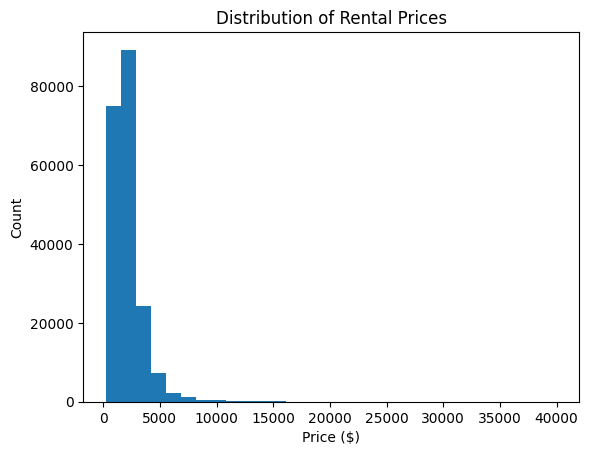

In [ ]:
# Histogram: Price
plt.hist(df['price'], bins=30)
plt.title("Distribution of Rental Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

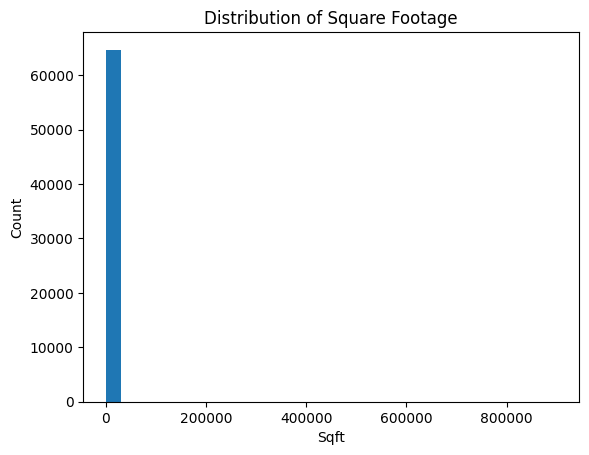

In [ ]:
# Histogram: Square Footage
plt.hist(df['sqft'].dropna(), bins=30)
plt.title("Distribution of Square Footage")
plt.xlabel("Sqft")
plt.ylabel("Count")
plt.show()


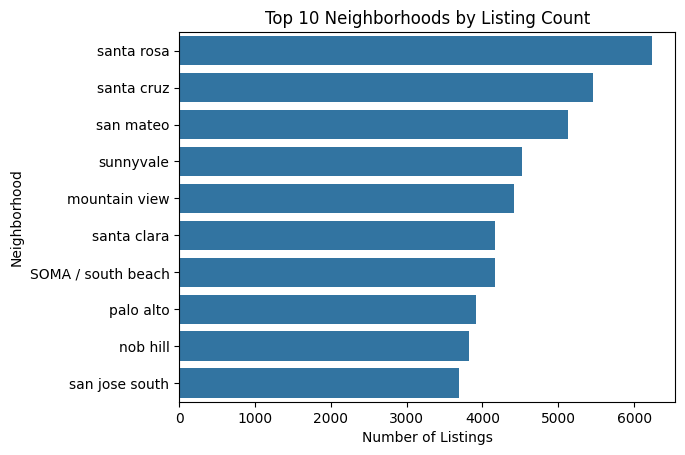

In [ ]:
# Bar plot of top 10 neighborhoods by number of listings
top_nhoods = df['nhood'].value_counts().head(10)

sns.barplot(x=top_nhoods.values, y=top_nhoods.index)
plt.title("Top 10 Neighborhoods by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Neighborhood")
plt.show()

### 🔧 Do the following – Part 3

1. Create two new visualizations using different variables than the ones already shown above.

>Suggestions:
- A **histogram** of the `baths` variable
- A **bar chart** showing the **average square footage by number of bathrooms**

> Be sure to label your axes and include a title for each chart.

### Reflection:

After creating each of the visuals, write 1–2 sentences explaining what you notice in each.


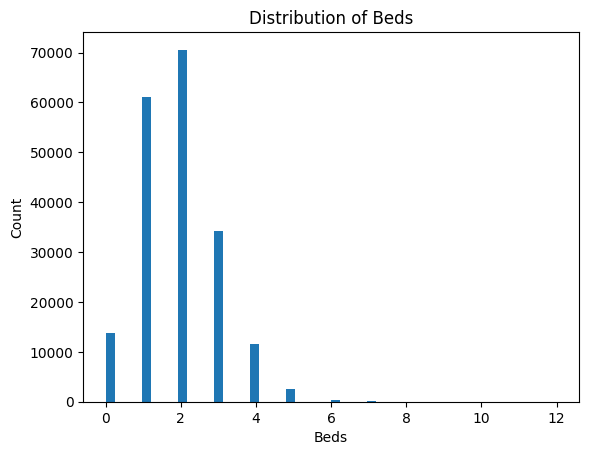

In [ ]:
plt.hist(df['beds'].dropna(), bins=50)
plt.title("Distribution of Beds")
plt.xlabel("Beds")
plt.ylabel("Count")
plt.show()

### ✍️ Visual 1 Response: 🔧
1.I wanted to verify the claim of beds being 0, rather than just assuming it represented a studio apartment. To do this, I reasoned that if there were many entries at 0, that would make it more likely to be a legitimate value rather than noise. The histogram confirmed several thousand entries at 0, which supports that this is a valid, meaningful category worth keeping. However, the max value of 12 beds appears highly unusual,the bar for it is nearly invisible at this scale, meaning only a tiny handful of listings if any actually have that many bedrooms, making it worth flagging as a potential invalid outlier.

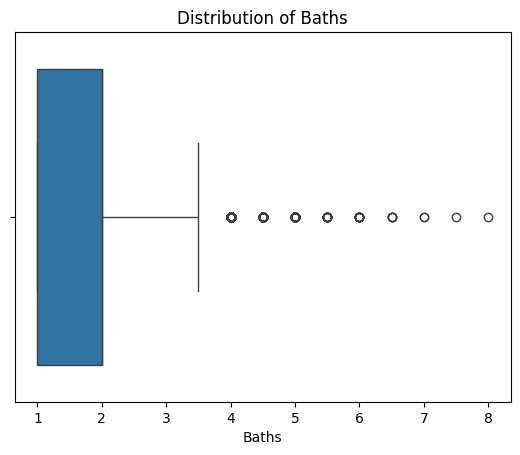

In [ ]:
sns.boxplot(x=df['baths'])
plt.title('Distribution of Baths')
plt.xlabel('Baths')
plt.show()

### ✍️ Visual 2 Response: 🔧
1. For Visual 2, I wanted to review the legitimacy of the 8-bath value, as well as the 50th and 75th percentiles both displaying the same value of 2. I figured the best way to visually convey this was with a boxplot, which confirmed my suspicions that the 50th and 75th percentiles are indeed the same, and the max of 8 baths is an extreme outlier, shown as individual dots stretching out beyond the main box.

## 4. Bivariate Analysis

Explore relationships between two variables to understand how features like square footage or bedrooms influence price.


In [ ]:
# Correlation matrix
corr_matrix = df[['price', 'beds', 'baths', 'sqft']].corr()
corr_matrix


,price,beds,baths,sqft
price,1.000000,0.450096,0.433553,0.074310
beds,0.450096,1.000000,0.651835,0.707235
baths,0.433553,0.651835,1.000000,0.645372
sqft,0.074310,0.707235,0.645372,1.000000


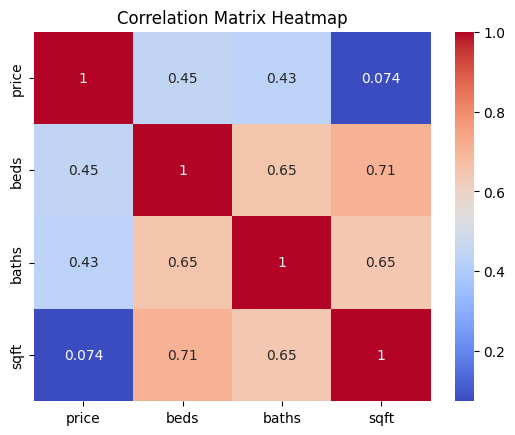

In [ ]:
# Heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

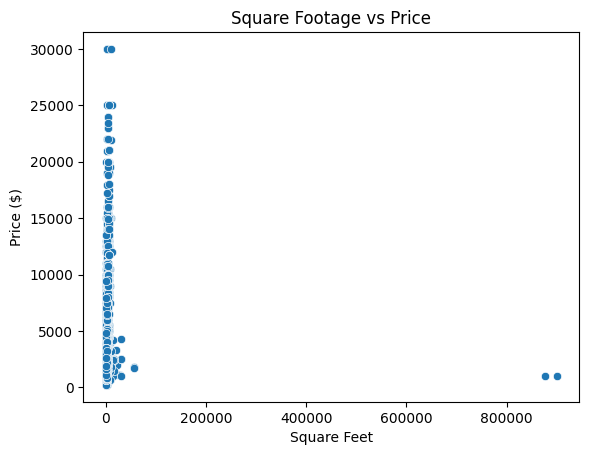

In [ ]:
# Scatterplot: Square Footage vs Price
sns.scatterplot(x='sqft', y='price', data=df)
plt.title("Square Footage vs Price")
plt.xlabel("Square Feet")
plt.ylabel("Price ($)")
plt.show()

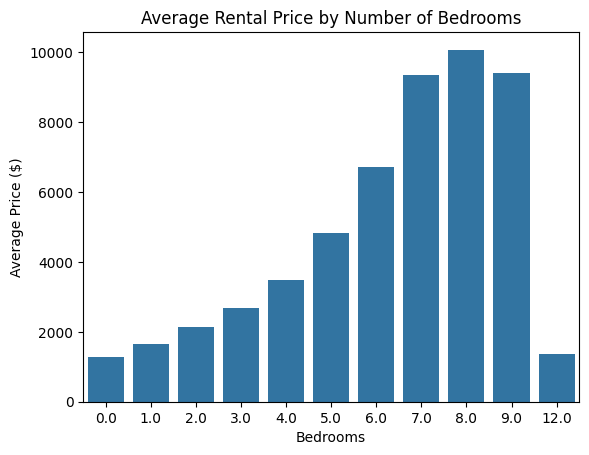

In [ ]:
# Average price by number of bedrooms
avg_price_beds = df.groupby('beds')['price'].mean().sort_index()
sns.barplot(x=avg_price_beds.index, y=avg_price_beds.values)
plt.title("Average Rental Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")
plt.show()

### 🔧 Do the following – Part 4

- 4.1 Create a scatterplot of `baths` vs `price`.  
- 4.2 Group by `year` and plot the average price over time.

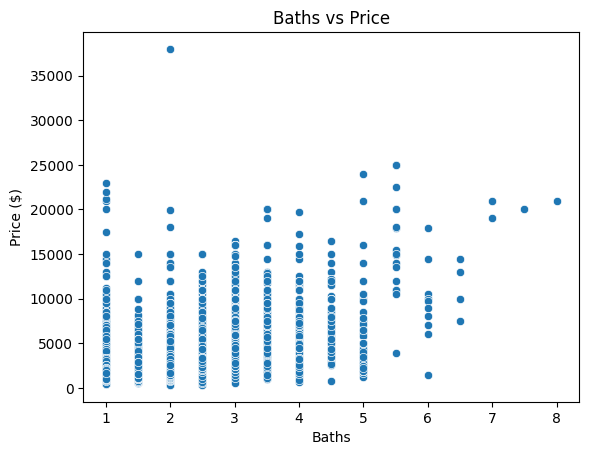

In [ ]:
sns.scatterplot(x='baths', y='price', data=df)
plt.title("Baths vs Price")
plt.xlabel("Baths")
plt.ylabel("Price ($)")
plt.show()

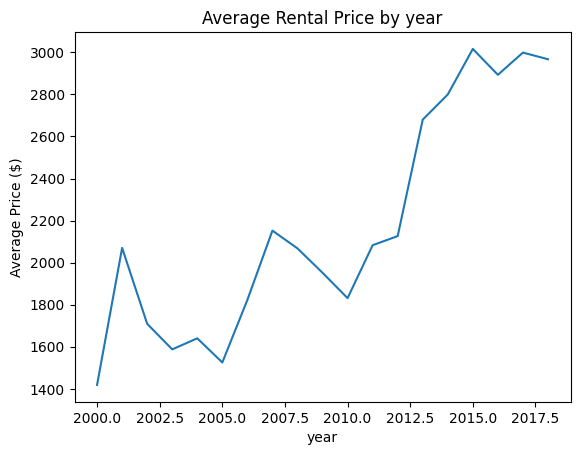

In [ ]:
avg_price_year = df.groupby('year')['price'].mean().sort_index()
avg_price_year.plot(kind='line')
plt.title("Average Rental Price by year")
plt.xlabel("year")
plt.ylabel("Average Price ($)")
plt.show()

### Reflection:
4.1 What trends or outliers do you see?

### ✍️ Your Response: 🔧
4.1 For the baths vs. price comparison, I see one major outlier a price above $35k despite it only being associated with 2 baths. I also notice that the max of 8 baths, while itself an outlier in the baths variable, actually falls in the higher end of the price range rather than being an extreme price outlier which is interesting, since you might expect the most extreme bath count to also produce the most extreme price. As for the year vs. price trend, the line shows prices generally increasing over time, with a dip around 2005, then a major spike from around 2010 through 2015, before leveling off near that high point through 2018.

## 🔧  Part 5: Reflection

Answer the following questions in the markdown cell below (no more than a few sentences per question required)

- 5.1 Which variables are most strongly correlated with rental price?
- 5.2 Are there patterns in how size (sqft) or number of bedrooms affects price?
- 5.3 Which neighborhoods or years show the highest prices?
- 5.4 What other visualizations or groupings might improve this analysis?

Use this section to summarize insights from both Labs 4 and 5.

### ✍️ Your Response: 🔧
5.1 The two strongest correlating factors with price are beds ".45" and baths ".43", based on the correlation heatmap.

5.2 The heatmap and scatterplot both show that sqft has little to no correlation with price rather in fact, it's the weakest of the four variables, at just   ".074". Whether this is due to corrupted data or a genuine lack of relationship, the other charts show only modest correlation overall. Bedrooms, on the other hand, show a clear upward trend with price. As bedroom count increases, so does average price, with the exception of the 12 bedroom outlier, which actually shows a low price relative to its bedroom count.

5.3 The highest average prices occur from roughly 2014 onward, where the spike happened before tapering off around 2017. Santa Rosa and Santa Cruz are the top two neighborhoods by number of listings.

5.4 I'd like to see a grouping comparing number of beds to number of baths, to check whether more bedrooms tends to predict more bathrooms in a rental. I'd also like to see sqft plotted against location, which could help explain the weak sqft-price correlation for example, larger properties might be concentrated in less desirable or less job-accessible areas. That would support a hypothesis that sqft isn't unimportant to price on its own, but that location may be a stronger underlying driver.


## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [ ]:
!jupyter nbconvert --to html "lab_05_eda.ipynb"

[NbConvertApp] WARNING | pattern 'lab_05_eda.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    